<a href="https://colab.research.google.com/github/biopharma26/PracticeNotebooks/blob/main/3_04_NGS_Troubleshooting_Case_Studies.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — NGS Workflow Troubleshooting: Case Studies

**Advanced Bioinformatics Lab Session**

## Learning objectives
- Integrate everything from Labs 1–3 into a diagnostic workflow: given only QC metrics, identify the root cause of a failed sequencing run
- Practice the standard NGS troubleshooting decision logic used in real cores/labs
- Build a reusable, rule-based QC triage function you can apply to any future dataset

## The troubleshooting reference table

| Symptom | Root cause | Fix |
|---|---|---|
| Low reads | Poor library preparation | Optimize prep |
| GC bias | PCR bias | PCR-free library |
| High duplication | Over-amplification | Reduce PCR cycles |
| Adapter contamination | Poor trimming | Use Cutadapt |
| Low mapping rate | Contamination | Clean reads |

In this lab you are handed **5 anonymized case studies** (simulated `MultiQC`-style summary reports) and must diagnose each one programmatically — exactly as you would triage a batch of failed runs in a sequencing core.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(99)
sns.set_theme(style="whitegrid", font_scale=1.05)


## 1. Generate 5 case-study QC reports

Each case study has one (or more) simulated defect injected. Your job in Section 3 is to recover the defect from the numbers alone — the "ground truth" column is hidden from you until the end.

In [ ]:
cases = {
    "Case_A": dict(total_reads=45_000_000, expected_reads=40_000_000, gc_content=0.41,
                   duplication_rate=0.09, adapter_contam=0.02, mapping_rate=0.96,
                   ground_truth="Healthy run"),
    "Case_B": dict(total_reads=6_200_000,  expected_reads=40_000_000, gc_content=0.40,
                   duplication_rate=0.11, adapter_contam=0.03, mapping_rate=0.93,
                   ground_truth="Low reads -> poor library prep"),
    "Case_C": dict(total_reads=41_000_000, expected_reads=40_000_000, gc_content=0.64,
                   duplication_rate=0.14, adapter_contam=0.02, mapping_rate=0.95,
                   ground_truth="GC bias -> PCR bias"),
    "Case_D": dict(total_reads=39_500_000, expected_reads=40_000_000, gc_content=0.42,
                   duplication_rate=0.58, adapter_contam=0.04, mapping_rate=0.94,
                   ground_truth="High duplication -> over-amplification"),
    "Case_E": dict(total_reads=42_000_000, expected_reads=40_000_000, gc_content=0.43,
                   duplication_rate=0.12, adapter_contam=0.27, mapping_rate=0.71,
                   ground_truth="Adapter contamination + low mapping rate -> poor trimming / contamination"),
}

report_df = pd.DataFrame(cases).T
report_df.index.name = "case"
report_display = report_df.drop(columns="ground_truth")
report_display


,total_reads,expected_reads,gc_content,duplication_rate,adapter_contam,mapping_rate
case,,,,,,
Case_A,45000000,40000000,0.41,0.09,0.02,0.96
Case_B,6200000,40000000,0.4,0.11,0.03,0.93
Case_C,41000000,40000000,0.64,0.14,0.02,0.95
Case_D,39500000,40000000,0.42,0.58,0.04,0.94
Case_E,42000000,40000000,0.43,0.12,0.27,0.71


## 2. Visualize all 5 cases against expected/pass thresholds

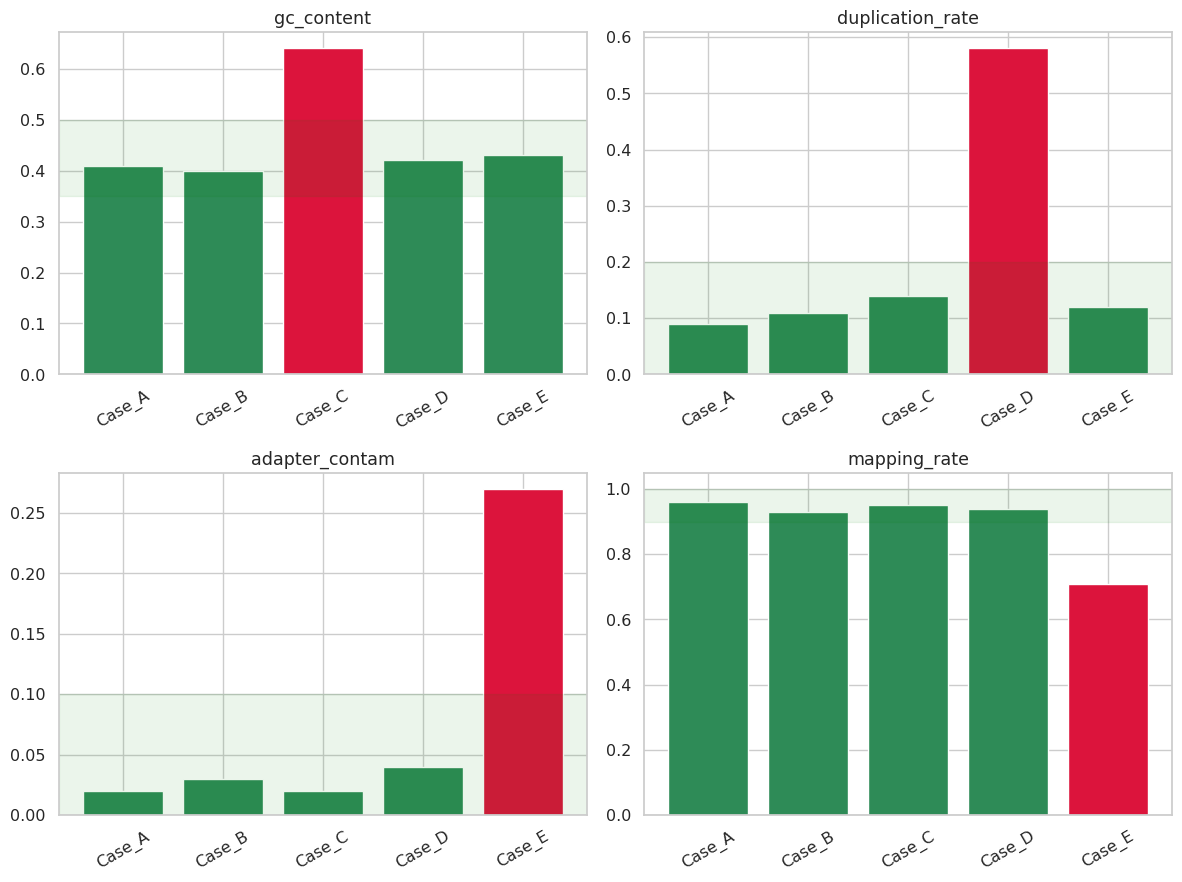

In [ ]:
thresholds = {
    "gc_content": (0.35, 0.50),          # acceptable range around ~41%
    "duplication_rate": (0.0, 0.20),     # FastQC-style flag above 20%
    "adapter_contam": (0.0, 0.10),
    "mapping_rate": (0.90, 1.0),
}

fig, axes = plt.subplots(2, 2, figsize=(12,9))
metrics = ["gc_content", "duplication_rate", "adapter_contam", "mapping_rate"]
for ax, metric in zip(axes.flat, metrics):
    vals = report_display[metric].astype(float)
    colors = ["seagreen" if thresholds[metric][0] <= v <= thresholds[metric][1] else "crimson" for v in vals]
    ax.bar(vals.index, vals.values, color=colors)
    ax.axhspan(thresholds[metric][0], thresholds[metric][1], color="green", alpha=0.08)
    ax.set_title(metric); ax.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()


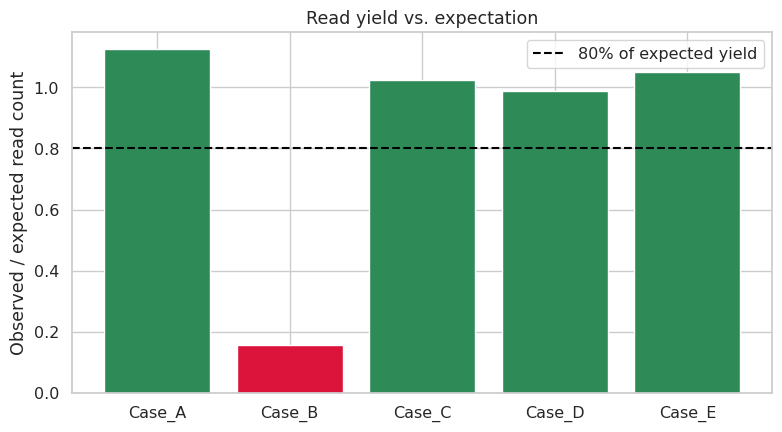

In [ ]:
plt.figure(figsize=(8,4.5))
read_ratio = (report_display["total_reads"] / report_display["expected_reads"]).astype(float)
colors = ["seagreen" if r >= 0.8 else "crimson" for r in read_ratio]
plt.bar(read_ratio.index, read_ratio.values, color=colors)
plt.axhline(0.8, color="black", linestyle="--", label="80% of expected yield")
plt.ylabel("Observed / expected read count"); plt.title("Read yield vs. expectation")
plt.legend(); plt.tight_layout(); plt.show()


## 3. Exercise — Build a rule-based QC triage function

Implement `diagnose(case_row)` below. It should return a **list of (symptom, root_cause, fix)** tuples for every threshold the case violates, using the reference table at the top of the notebook. Test it against all 5 cases before revealing the ground truth in Section 4.

In [ ]:
def diagnose(row):
    """row: a pandas Series with keys total_reads, expected_reads, gc_content,
    duplication_rate, adapter_contam, mapping_rate. Returns list of (symptom, cause, fix)."""
    findings = []

    # --- YOUR CODE HERE ---
    # Hint: compare row['total_reads']/row['expected_reads'] to 0.8
    # Hint: compare row['gc_content'] to the 0.35-0.50 healthy band
    # Hint: compare row['duplication_rate'] to 0.20
    # Hint: compare row['adapter_contam'] to 0.10
    # Hint: compare row['mapping_rate'] to 0.90

    if row["total_reads"] / row["expected_reads"] < 0.8:
        findings.append(("Low reads", "Poor library preparation", "Optimize library prep"))
    if not (0.35 <= row["gc_content"] <= 0.50):
        findings.append(("GC bias", "PCR bias", "Use PCR-free library prep"))
    if row["duplication_rate"] > 0.20:
        findings.append(("High duplication", "Over-amplification", "Reduce PCR cycles"))
    if row["adapter_contam"] > 0.10:
        findings.append(("Adapter contamination", "Poor trimming", "Use Cutadapt"))
    if row["mapping_rate"] < 0.90:
        findings.append(("Low mapping rate", "Contamination", "Clean reads (decontaminate + re-trim)"))

    if not findings:
        findings.append(("None", "Healthy run", "No action needed"))
    return findings

for case_name, row in report_display.iterrows():
    print(f"\n{case_name}:")
    for symptom, cause, fix in diagnose(row):
        print(f"  - {symptom}: {cause} -> {fix}")



Case_A:
  - None: Healthy run -> No action needed

Case_B:
  - Low reads: Poor library preparation -> Optimize library prep

Case_C:
  - GC bias: PCR bias -> Use PCR-free library prep

Case_D:
  - High duplication: Over-amplification -> Reduce PCR cycles

Case_E:
  - Adapter contamination: Poor trimming -> Use Cutadapt
  - Low mapping rate: Contamination -> Clean reads (decontaminate + re-trim)


## 4. Reveal ground truth and self-check

In [ ]:
check_df = report_df[["ground_truth"]].copy()
check_df["your_diagnosis"] = [
    "; ".join(f"{s} ({c})" for s, c, _ in diagnose(report_display.loc[idx]))
    for idx in report_display.index
]
check_df


,ground_truth,your_diagnosis
case,,
Case_A,Healthy run,None (Healthy run)
Case_B,Low reads -> poor library prep,Low reads (Poor library preparation)
Case_C,GC bias -> PCR bias,GC bias (PCR bias)
Case_D,High duplication -> over-amplification,High duplication (Over-amplification)
Case_E,Adapter contamination + low mapping rate -> po...,Adapter contamination (Poor trimming); Low map...


## 5. Extension exercise — the compound case

`Case_E` fails on **two** metrics simultaneously (adapter contamination *and* low mapping rate). In practice these are often linked: untrimmed adapter sequence at the 3′ end of reads causes the aligner to soft-clip or fail to map those reads at all.

1. Modify the simulated adapter-trimming function from **Lab 2** to clean `Case_E`-like reads.
2. Argue, in 2–3 sentences, why fixing adapter contamination *first* is likely to partially fix the low mapping rate too — i.e., why these two symptoms might share one root fix rather than needing two independent ones.
3. Design one **new** case (Case_F) with a defect combination not covered above (e.g. low reads + high duplication together) and run it through your `diagnose()` function to confirm it correctly reports both.

In [ ]:
# Case_F — design your own compound-defect case here
case_f = dict(total_reads=5_500_000, expected_reads=40_000_000, gc_content=0.42,
              duplication_rate=0.61, adapter_contam=0.03, mapping_rate=0.92)
case_f_series = pd.Series(case_f)
print("Case_F diagnosis:")
for symptom, cause, fix in diagnose(case_f_series):
    print(f"  - {symptom}: {cause} -> {fix}")


Case_F diagnosis:
  - Low reads: Poor library preparation -> Optimize library prep
  - High duplication: Over-amplification -> Reduce PCR cycles


## 6. Wrap-up

You've now practiced the full arc of an NGS QC/troubleshooting workflow:

- **Lab 1**: chose the right platform chemistry for the biological question
- **Lab 2**: generated and QC'd raw FASTQ data, fixed adapter contamination
- **Lab 3**: went from raw counts to biological interpretation (single-cell clusters, spatial tumor microenvironment)
- **Lab 4**: triaged failed runs using a rule-based diagnostic system

**Discussion**: In a real sequencing core, would you rather this `diagnose()` logic run automatically inside a MultiQC/Nextflow pipeline, or reviewed manually by a bioinformatician before any samples are re-run? What are the risks of over-automating this decision?
